# Image Classification with larger CNN

The goal of this exercise is to program a slightly larger CNN that incorporates some of the ideas that have been presented in the class. We use CIFAR-100, which is a bit more challenging than the MNIST data set, but not so much. It contains 50000 images that are labelled into 100 fine-grained classes of 20 more coarse grained classes. In order to make the task a mit more complicated we will use the fine grained classes.

The dataset is build into keras.

In [1]:
import keras
import keras.datasets
import keras.datasets.cifar100
import keras.utils
import keras.optimizers
import numpy as np

import matplotlib.pyplot as plt

print(keras.__version__)

3.11.3


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

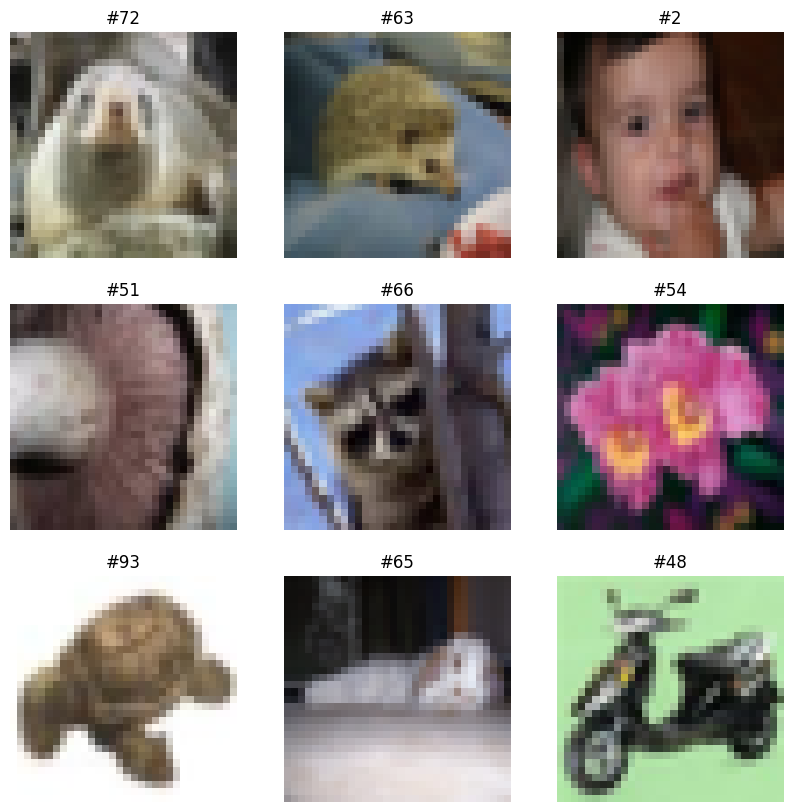

In [3]:
plt.figure(figsize=(10, 10))
for i in range(9):
    index = np.random.randint(50000)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(x_train[index]).astype("uint8"))
    plt.title(f'#{(y_train[index][0])}')
    plt.axis("off")

In [4]:
num_classes = 100
# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [6]:
def build_model():
    inp = keras.Input(shape=(32, 32, 3))
    x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(inp)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu")(x)
    #x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(100, activation='softmax')(x)
                        
    return keras.Model(inp, x)

In [7]:
model = build_model()

In [34]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,298 (2.27 MB)

 Trainable params: 298,148 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 298,150 (1.14 MB)

In [9]:
batch_size = 128
epochs = 15
opt = keras.optimizers.RMSprop(learning_rate=0.01)
model = build_model()
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.0489 - loss: 4.3924 - val_accuracy: 0.1130 - val_loss: 3.8666
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1372 - loss: 3.7538 - val_accuracy: 0.1634 - val_loss: 3.5931
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1801 - loss: 3.5170 - val_accuracy: 0.1484 - val_loss: 3.7185
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.2022 - loss: 3.3861 - val_accuracy: 0.1660 - val_loss: 3.6515
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.2190 - loss: 3.2945 - val_accuracy: 0.1840 - val_loss: 3.5044
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.2316 - loss: 3.2370 - val_accuracy: 0.1968 - val_loss: 3.4619
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.2426 - loss: 3.1700 - val_accuracy: 0.1696 - val_loss: 3.6468
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.2515 - loss: 3.1209 - val_

The performance is not bad, but also not so great. The best results without using additional data for convolutional neural networks is at about 70 percent.

In [10]:
print(history.history)

{'accuracy': [0.04893333464860916, 0.13717778027057648, 0.18013332784175873, 0.2021999955177307, 0.21899999678134918, 0.2315777838230133, 0.2425999939441681, 0.2515333294868469, 0.2593555450439453, 0.2703111171722412, 0.27551111578941345, 0.28155556321144104, 0.2891555428504944, 0.2982666790485382, 0.30317777395248413], 'loss': [4.392378807067871, 3.753754138946533, 3.5169973373413086, 3.3860690593719482, 3.2944910526275635, 3.236994743347168, 3.1699540615081787, 3.1209299564361572, 3.0795834064483643, 3.0399527549743652, 3.0000922679901123, 2.961939573287964, 2.9341087341308594, 2.879016876220703, 2.847137212753296], 'val_accuracy': [0.11299999803304672, 0.16339999437332153, 0.14839999377727509, 0.16599999368190765, 0.18400000035762787, 0.19679999351501465, 0.1695999950170517, 0.21480000019073486, 0.18019999563694, 0.21199999749660492, 0.20160000026226044, 0.20200000703334808, 0.20839999616146088, 0.20819999277591705, 0.20399999618530273], 'val_loss': [3.8666446208953857, 3.5931355953

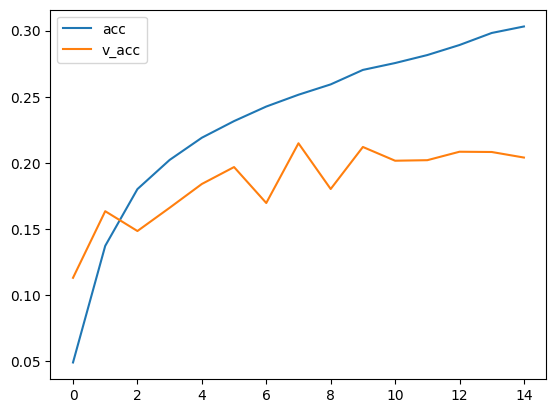

In [11]:
fig, ax = plt.subplots()
ax.plot(history.history['accuracy'], label='acc')
ax.plot( history.history['val_accuracy'], label='v_acc')
plt.legend()
plt.show()

## Exercise 1: Modern CNN

A *modern* CNN should have some of the features discussed in the lecture. Build a model that includes some or all of these:
- ResNet architecture with skip connections
- Batch Normalization
- L2 Regularisation
- Dropout

How does you model perform?

In [65]:
def build_custom_model():
    inp = keras.Input(shape=(32, 32, 3))
    a = keras.layers.SeparableConv2D(filters=16, kernel_size=3, activation="relu")(inp)
    # a = keras.layers.MaxPooling2D(pool_size=(2, 2))(a)
    a = keras.layers.Dropout(0.4)(a)
    
    a = keras.layers.SeparableConv2D(filters=32, kernel_size=3, activation="relu")(a)
    # a = keras.layers.MaxPooling2D(pool_size=(2, 2))(a)
        
    b = keras.layers.SeparableConv2D(filters=32, kernel_size=3, padding="same", activation="relu")(a)
    b = keras.layers.SeparableConv2D(filters=32, kernel_size=3, padding="same")(b)
    b = keras.layers.Add()([a, b]) # ResBlock
    b = keras.layers.Dropout(0.4)(b)

    b = keras.layers.SeparableConv2D(filters=32, kernel_size=3, padding="same")(b)
    b = keras.layers.Dropout(0.4)(b)
    
    b = keras.layers.SeparableConv2D(filters=128, kernel_size=3, activation="relu")(b)
    b = keras.layers.MaxPooling2D(pool_size=(2, 2))(b)
    b = keras.layers.Dropout(0.4)(b)
    b = keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(b)  # Normalize activations
    
    b = keras.layers.Flatten()(b)
    b = keras.layers.Dense(100, activation='softmax')(b) # We have to classify 100 categories of images
                        
    return keras.Model(inp, b)

In [66]:
custom_model = build_custom_model()

In [67]:
custom_model.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 30, 30,    │         91 │ input_layer_26[0… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_87          │ (None, 30, 30,    │          0 │ separable_conv2d… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 28, 28,    │        688 │ dropout_87[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 28, 28,    │      1,344 │ separable_conv2d… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 28, 28,    │      1,344 │ separable_conv2d… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_26 (Add)        │ (None, 28, 28,    │          0 │ separable_conv2d… │
│                     │ 32)               │            │ separable_conv2d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_88          │ (None, 28, 28,    │          0 │ add_26[0][0]      │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 28, 28,    │      1,344 │ dropout_88[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_89          │ (None, 28, 28,    │          0 │ separable_conv2d… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_5  │ (None, 26, 26,    │      4,512 │ dropout_89[0][0]  │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_75    │ (None, 13, 13,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_90          │ (None, 13, 13,    │          0 │ max_pooling2d_75… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 13,    │        512 │ dropout_90[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_25          │ (None, 21632)     │          0 │ batch_normalizat… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 100)       │  2,163,300 │ flatten_25[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,173,135 (8.29 MB)

 Trainable params: 2,172,879 (8.29 MB)

 Non-trainable params: 256 (1.00 KB)

In [68]:
batch_size = 128
epochs = 15
opt = keras.optimizers.RMSprop(learning_rate=0.01)
custom_model = build_custom_model()
custom_model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

history_custom = custom_model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - accuracy: 0.0094 - loss: 4.7208 - val_accuracy: 0.0106 - val_loss: 4.7376
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.0097 - loss: 4.7111 - val_accuracy: 0.0106 - val_loss: 4.7592
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 145ms/step - accuracy: 0.0091 - loss: 4.7114 - val_accuracy: 0.0078 - val_loss: 4.7440
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.0096 - loss: 4.7090 - val_accuracy: 0.0088 - val_loss: 4.7693
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 54s 153ms/step - accuracy: 0.0100 - loss: 4.7081 - val_accuracy: 0.0074 - val_loss: 4.7495
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.0095 - loss: 4.7099 - val_accuracy: 0.0090 - val_loss: 4.8111
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.0094 - loss: 4.7096 - val_accuracy: 0.0096 - val_loss: 4.7417
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.0107 - loss: 4.7

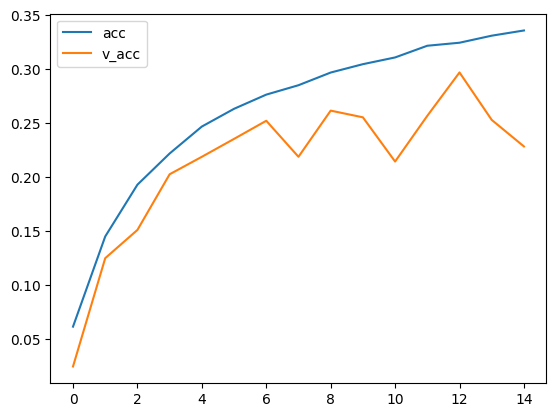

In [67]:
fig, ax = plt.subplots()
ax.plot(history_custom.history['accuracy'], label='acc')
ax.plot(history_custom.history['val_accuracy'], label='v_acc')
plt.legend()
plt.show()

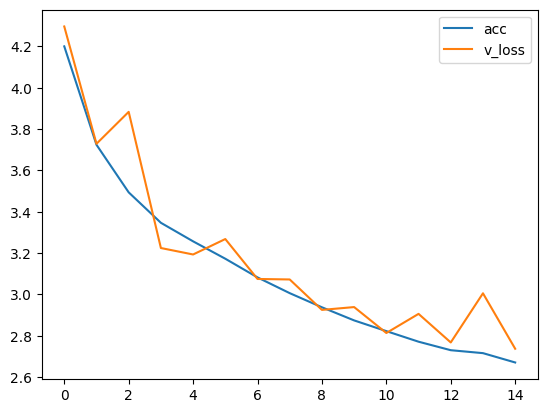

In [13]:
fig, ax = plt.subplots()
ax.plot(history_custom.history['loss'], label='acc')
ax.plot(history_custom.history['val_loss'], label='v_loss')
plt.legend()
plt.show()

## Exercise 2: Monitoring

Monitoring the training is essential for long running training sessions. Include tensorboard or wandb in your training setup.

In [15]:
%load_ext tensorboard
import tensorflow as tf
import datetime

In [35]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

batch_size = 128
epochs = 20
opt = keras.optimizers.RMSprop(learning_rate=0.01)
custom_model = build_custom_model()
custom_model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

custom_model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, callbacks=[tensorboard_callback])

Epoch 1/20


ValueError: Exception encountered when calling MaxPooling2D.call().

[1mNegative dimension size caused by subtracting 2 from 1 for '{{node functional_12_1/max_pooling2d_42_1/MaxPool2d}} = MaxPool[T=DT_FLOAT, data_format="NHWC", explicit_paddings=[], ksize=[1, 2, 2, 1], padding="VALID", strides=[1, 2, 2, 1]](functional_12_1/conv2d_64_1/Relu)' with input shapes: [?,1,1,128].[0m

Arguments received by MaxPooling2D.call():
  • inputs=tf.Tensor(shape=(None, 1, 1, 128), dtype=float32)

In [16]:
%tensorboard --logdir logs/fit
# http://localhost:6006

Reusing TensorBoard on port 6006 (pid 7560), started 1 day, 12:35:26 ago. (Use '!kill 7560' to kill it.)

## Exercise 3: Data Augmentation (continued next lesson)

What else could be done to get better results? The dataset is quite small, so either another dataset could be used for pretraining, or data augmentation could be added....